In [1]:
# Core Library Imports and Environment Configuration
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')


In [2]:
#  Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/Ngao Labs/Ngao_Capstone_Project'

Mounted at /content/drive


In [3]:
 # Ingesting Data and Typing Temporal Features
try:
    print("Initiating data ingestion sequence...")
    df_demographics = pd.read_csv(os.path.join(DATA_PATH, 'traindemographics.csv'), parse_dates=['birthdate'])
    prev_date_cols = ['approveddate', 'creationdate', 'closeddate', 'firstduedate', 'firstrepaiddate']
    df_prevloans = pd.read_csv(os.path.join(DATA_PATH, 'trainprevloans.csv'), parse_dates=prev_date_cols)
    perf_date_cols = ['approveddate', 'creationdate']
    df_perf = pd.read_csv(os.path.join(DATA_PATH, 'trainperf.csv'), parse_dates=perf_date_cols)
except Exception as e:
    print(f"Critical Data Ingestion Error: {e}")

Initiating data ingestion sequence...


In [4]:
 # Cleaning Protocol, Target Encoding, and Deduplication
target_mapping = {'Good': 0, 'Bad': 1}
if 'good_bad_flag' in df_perf.columns:
    df_perf['default_flag'] = df_perf['good_bad_flag'].map(target_mapping)
    df_perf.drop('good_bad_flag', axis=1, inplace=True)

columns_to_drop = ['longitude_gps', 'latitude_gps', 'bank_branch_clients']
existing_cols_to_drop = [col for col in columns_to_drop if col in df_demographics.columns]
df_demographics.drop(columns=existing_cols_to_drop, axis=1, inplace=True)

df_demographics.drop_duplicates(subset=['customerid'], keep='last', inplace=True)
df_perf.drop_duplicates(subset=['customerid'], keep='last', inplace=True)

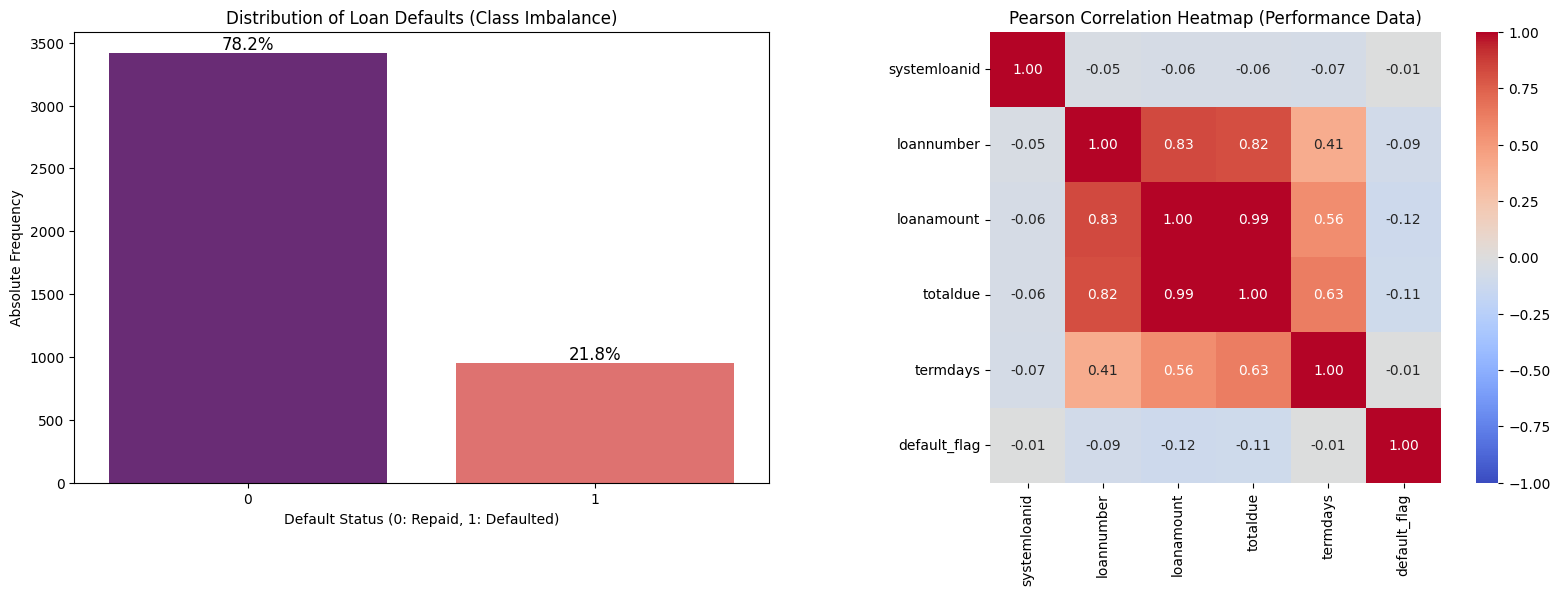

Overall Default Rate Analysis: The portfolio exhibits a default rate of 21.79%.


In [5]:

#  Exploratory Data Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df_perf, x='default_flag', palette='magma', ax=axes[0])
axes[0].set_title('Distribution of Loan Defaults (Class Imbalance)')
axes[0].set_xlabel('Default Status (0: Repaid, 1: Defaulted)')
axes[0].set_ylabel('Absolute Frequency')

total_samples = len(df_perf)
for p in axes[0].patches:
    percentage = f'{100 * p.get_height() / total_samples:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    axes[0].annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12)

perf_numeric = df_perf.select_dtypes(include=['int64', 'float64'])
corr_matrix = perf_numeric.corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Pearson Correlation Heatmap (Performance Data)')

plt.tight_layout()
plt.show()

default_rate = df_perf['default_flag'].mean() * 100
print(f"Overall Default Rate Analysis: The portfolio exhibits a default rate of {default_rate:.2f}%.")